In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


In [11]:
path = '/Users/shalindri/Documents/MSc/pds/CW/GroupWork/GIT2/PrinciplesOfDataScience_Group2/data/time_series_data.csv'

In [13]:
df = pd.read_csv(path)
df.head()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
0,1,197,66,266,113,2,1,18
1,2,153,44,264,74,1,2,21
2,3,128,55,317,116,0,1,19
3,4,133,57,390,70,0,2,17
4,5,120,47,440,141,1,1,18


In [15]:
df.tail()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
95,96,174,226,975,94,0,1,2
96,97,158,201,1141,91,0,2,3
97,98,145,217,881,46,4,1,3
98,99,161,249,741,70,0,1,7
99,100,160,331,854,75,0,1,5


In [17]:
df.describe()

,t,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature
count,100.000000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,148.370000,153.440000,631.5800,80.120000,0.550000,1.470000,13.020000
std,29.011492,18.061989,68.164288,202.8871,36.780891,1.225775,0.501614,5.915192
min,1.000000,107.000000,42.000000,203.0000,11.000000,0.000000,1.000000,2.000000
25%,25.750000,134.000000,95.500000,491.7500,55.750000,0.000000,1.000000,9.000000
50%,50.500000,151.000000,155.500000,611.0000,70.000000,0.000000,1.000000,13.000000
75%,75.250000,160.000000,200.250000,770.5000,100.250000,0.000000,2.000000,17.000000
max,100.000000,197.000000,331.000000,1141.0000,194.000000,5.000000,2.000000,26.000000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   t            100 non-null    int64
 1   ProductP1    100 non-null    int64
 2   ProductP2    100 non-null    int64
 3   ProductP3    100 non-null    int64
 4   ProductP4    100 non-null    int64
 5   ProductP5    100 non-null    int64
 6   price        100 non-null    int64
 7   temperature  100 non-null    int64
dtypes: int64(8)
memory usage: 6.4 KB


### Weekly data preparation

In [22]:
import pandas as pd
from datetime import timedelta

df2 = df.copy()

# Last date
last_date = pd.to_datetime('2019-08-30')

# Calculate the starting date
start_date = last_date - timedelta(weeks=99)

# Generate a date range
date_range = pd.date_range(start=start_date, periods=100, freq='W')

# Map the 't' column to the date range
df2['date'] = df2['t'].apply(lambda x: date_range[x-1])

# Drop the 't' column
df2.drop(columns=['t'], inplace=True)


df2.head()

,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature,date
0,197,66,266,113,2,1,18,2017-10-08
1,153,44,264,74,1,2,21,2017-10-15
2,128,55,317,116,0,1,19,2017-10-22
3,133,57,390,70,0,2,17,2017-10-29
4,120,47,440,141,1,1,18,2017-11-05


In [24]:
# Select the necessary columns
weekly_data = df2[["date", "ProductP1", "ProductP2", "ProductP5"]]
weekly_data.head()

,date,ProductP1,ProductP2,ProductP5
0,2017-10-08,197,66,2
1,2017-10-15,153,44,1
2,2017-10-22,128,55,0
3,2017-10-29,133,57,0
4,2017-11-05,120,47,1


### Daily data preparation

In [27]:
df3 = df.copy()

# Last date
last_date = pd.to_datetime('2019-11-24')

# Calculate the starting date
start_date = last_date - timedelta(days=99)

# Generate a date range
date_range = pd.date_range(start=start_date, periods=100, freq='D')

# Map the 't' column to the date range
df3['date'] = df3['t'].apply(lambda x: date_range[x-1])

# Drop the original 't' column
df3.drop(columns=['t'], inplace=True)

df3.head()

,ProductP1,ProductP2,ProductP3,ProductP4,ProductP5,price,temperature,date
0,197,66,266,113,2,1,18,2019-08-17
1,153,44,264,74,1,2,21,2019-08-18
2,128,55,317,116,0,1,19,2019-08-19
3,133,57,390,70,0,2,17,2019-08-20
4,120,47,440,141,1,1,18,2019-08-21


In [29]:
# Select the necessary columns
daily_data = df3[["date", "ProductP3", "ProductP4", "price", "temperature"]]
daily_data.head()

,date,ProductP3,ProductP4,price,temperature
0,2019-08-17,266,113,1,18
1,2019-08-18,264,74,2,21
2,2019-08-19,317,116,1,19
3,2019-08-20,390,70,2,17
4,2019-08-21,440,141,1,18


In [31]:
weekly_data.describe().T

,count,mean,min,25%,50%,75%,max,std
date,100,2018-09-19 12:00:00,2017-10-08 00:00:00,2018-03-30 06:00:00,2018-09-19 12:00:00,2019-03-11 18:00:00,2019-09-01 00:00:00,NaN
ProductP1,100.0,148.37,107.0,134.0,151.0,160.0,197.0,18.061989
ProductP2,100.0,153.44,42.0,95.5,155.5,200.25,331.0,68.164288
ProductP5,100.0,0.55,0.0,0.0,0.0,0.0,5.0,1.225775


### EDA

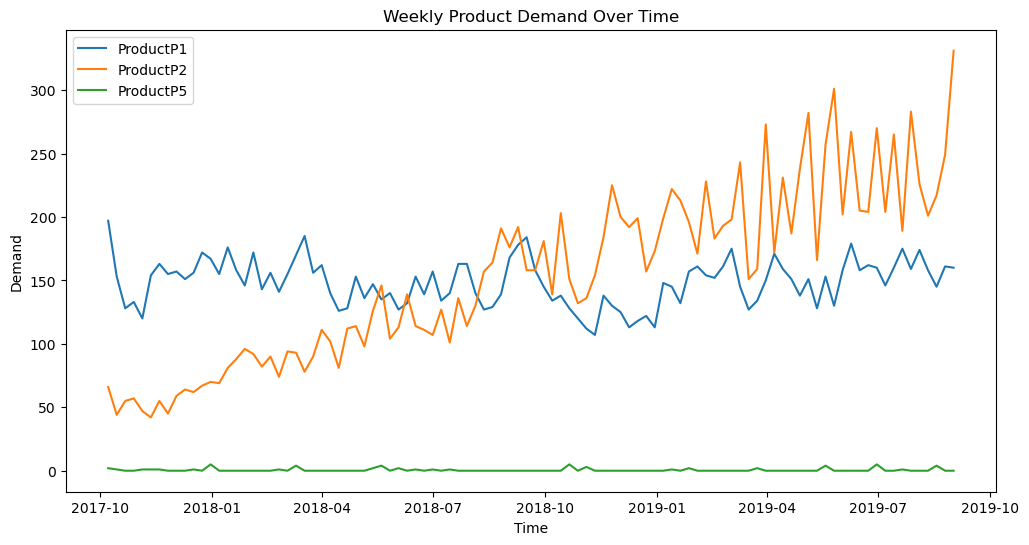

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(weekly_data["date"], weekly_data["ProductP1"], label="ProductP1")
plt.plot(weekly_data["date"], weekly_data["ProductP2"], label="ProductP2")
plt.plot(weekly_data["date"], weekly_data["ProductP5"], label="ProductP5")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.title("Weekly Product Demand Over Time")
plt.show()

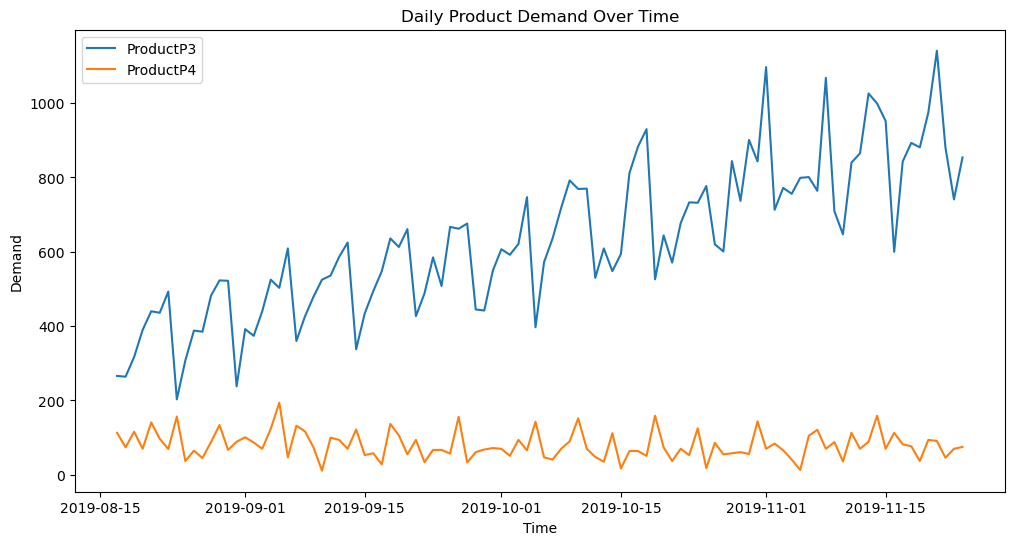

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(daily_data["date"], daily_data["ProductP3"], label="ProductP3")
plt.plot(daily_data["date"], daily_data["ProductP4"], label="ProductP4")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.title("Daily Product Demand Over Time")
plt.show()

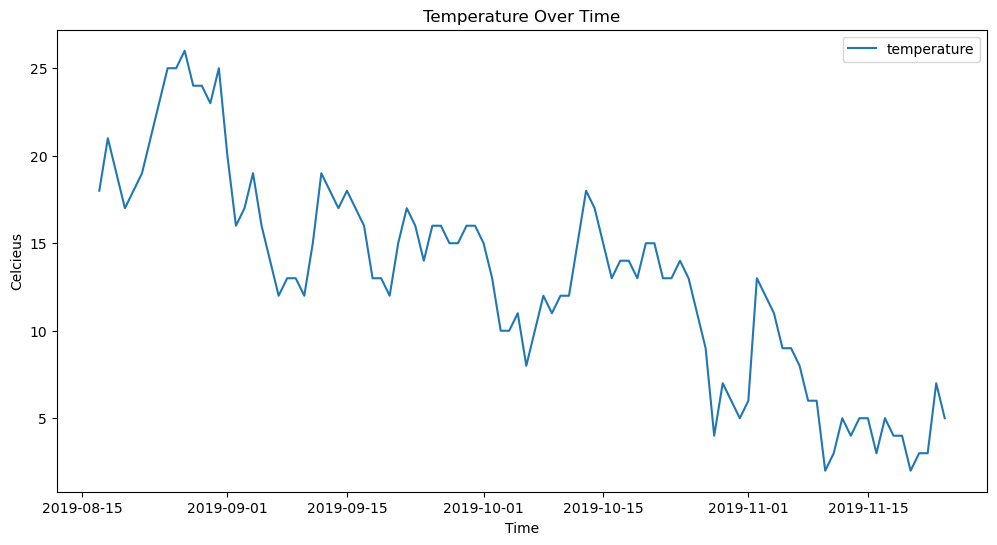

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(daily_data["date"], daily_data["temperature"], label="temperature")
plt.xlabel("Time")
plt.ylabel("Celcieus")
plt.legend()
plt.title("Temperature Over Time")
plt.show()

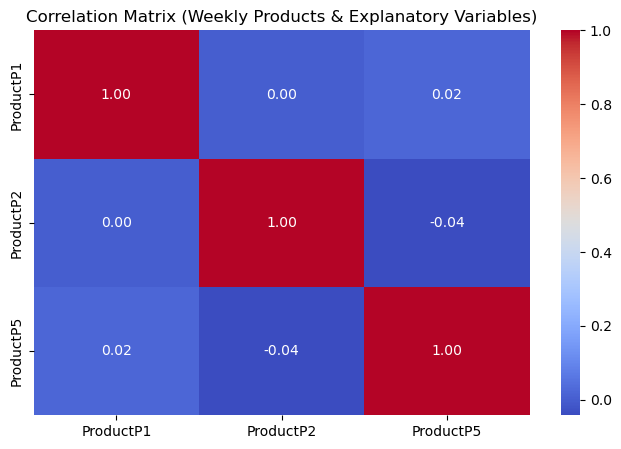

In [40]:
# Compute correlation matrix for weekly products
corr_matrix = weekly_data[["ProductP1", "ProductP2", "ProductP5"]].corr()

# correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Weekly Products & Explanatory Variables)")
plt.show()

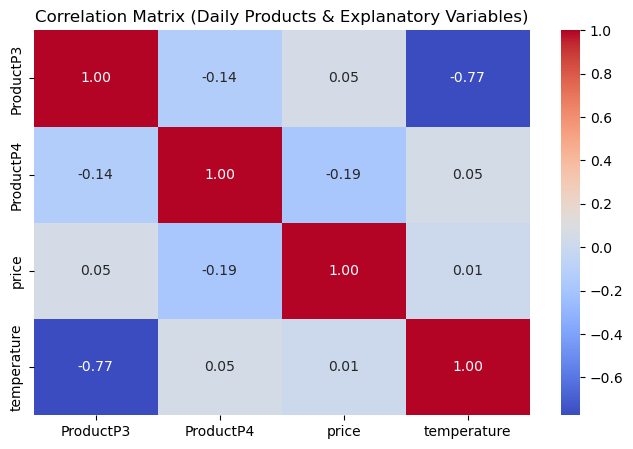

In [42]:
# Compute correlation matrix for daily products
corr_matrix = daily_data[["ProductP3", "ProductP4", "price", "temperature"]].corr()

# correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Daily Products & Explanatory Variables)")
plt.show()

### Weekly Data Clustering

In [47]:
# Standardize the data
scaler = StandardScaler()
wd_scaled = scaler.fit_transform(weekly_data[["ProductP1", "ProductP2", "ProductP5"]])

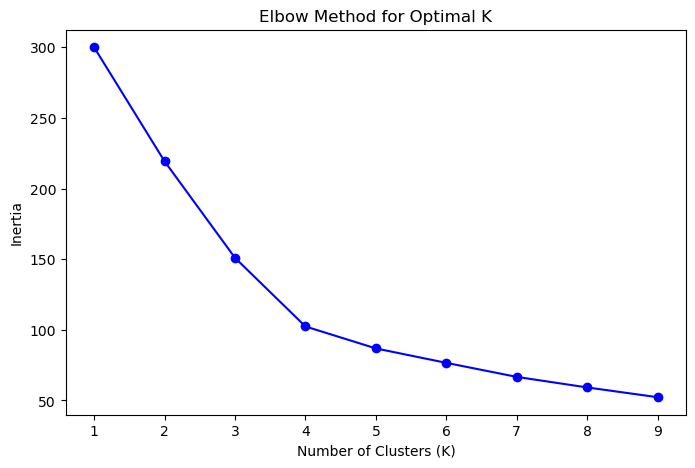

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import numpy as np

# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(wd_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [50]:
# Apply PCA with all components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(wd_scaled)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

PC1: 0.3488 (Cumulative: 0.3488)
PC2: 0.3333 (Cumulative: 0.6822)
PC3: 0.3178 (Cumulative: 1.0000)


In [53]:
# Choose the optimal number of clusters (based on the Elbow method)
optimal_k = 4

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
weekly_data["Cluster"] = kmeans.fit_predict(wd_scaled)

/var/folders/c4/lp7tf77d1j5_vh5zsl8h57_h0000gn/T/ipykernel_99098/1826665429.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weekly_data["Cluster"] = kmeans.fit_predict(wd_scaled)


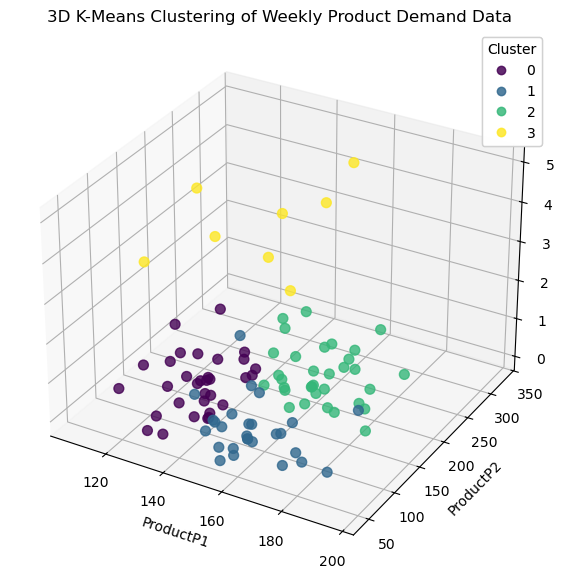

In [55]:
# Apply PCA with n_components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(wd_scaled)

# 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(weekly_data["ProductP1"], weekly_data["ProductP2"], weekly_data["ProductP5"], 
                      c=weekly_data["Cluster"], cmap="viridis", s=50, alpha=0.8)

ax.set_xlabel("ProductP1")
ax.set_ylabel("ProductP2")
ax.set_zlabel("ProductP5")
ax.set_title("3D K-Means Clustering of Weekly Product Demand Data")

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

/var/folders/c4/lp7tf77d1j5_vh5zsl8h57_h0000gn/T/ipykernel_99098/3703218588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weekly_data["Cluster"] = weekly_data["Cluster"].astype(str)


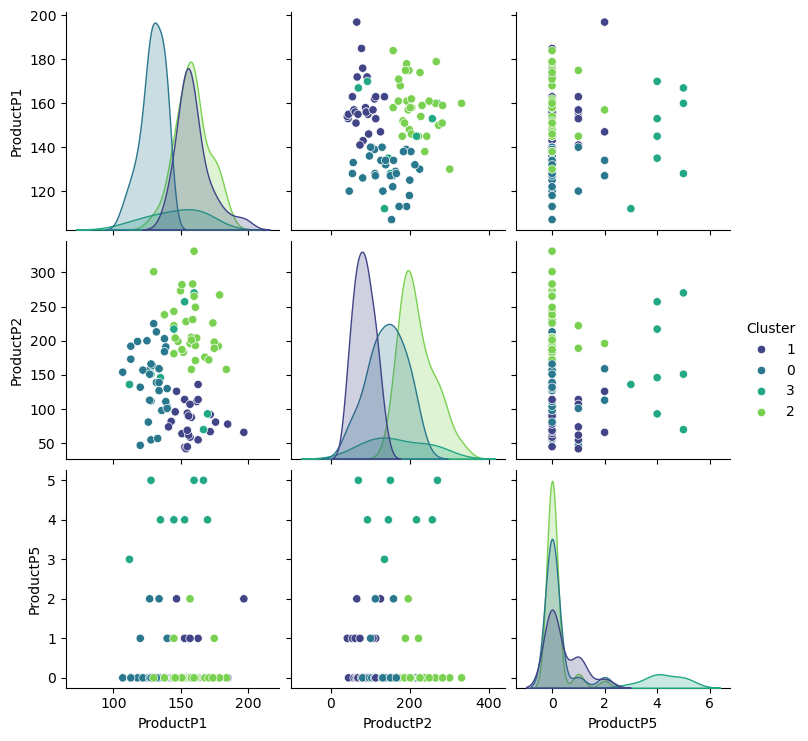

In [56]:
# Pair plot
weekly_data["Cluster"] = weekly_data["Cluster"].astype(str)
sns.pairplot(weekly_data, hue="Cluster", palette="viridis", diag_kind="kde")

### Daily data clustering


In [60]:
daily_data.describe().T


,count,mean,min,25%,50%,75%,max,std
date,100,2019-10-05 12:00:00,2019-08-17 00:00:00,2019-09-10 18:00:00,2019-10-05 12:00:00,2019-10-30 06:00:00,2019-11-24 00:00:00,NaN
ProductP3,100.0,631.58,203.0,491.75,611.0,770.5,1141.0,202.8871
ProductP4,100.0,80.12,11.0,55.75,70.0,100.25,194.0,36.780891
price,100.0,1.47,1.0,1.0,1.0,2.0,2.0,0.501614
temperature,100.0,13.02,2.0,9.0,13.0,17.0,26.0,5.915192


In [66]:
# Standardize the data
dd_scaled = scaler.fit_transform(daily_data[["ProductP3", "ProductP4", "price", "temperature"]])

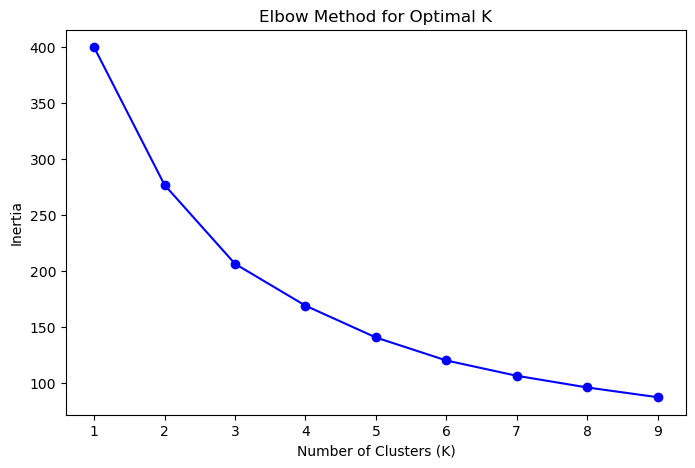

In [68]:
# Determine the optimal number of clusters using the Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dd_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [70]:
# Apply PCA with all components
pca = PCA(n_components=4)
X_pca = pca.fit_transform(dd_scaled)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"PC{i}: {var:.4f} (Cumulative: {cum_var:.4f})")

PC1: 0.4500 (Cumulative: 0.4500)
PC2: 0.2942 (Cumulative: 0.7442)
PC3: 0.2009 (Cumulative: 0.9451)
PC4: 0.0549 (Cumulative: 1.0000)


/var/folders/c4/lp7tf77d1j5_vh5zsl8h57_h0000gn/T/ipykernel_99098/3440090208.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data["Cluster"] = kmeans.fit_predict(dd_scaled)


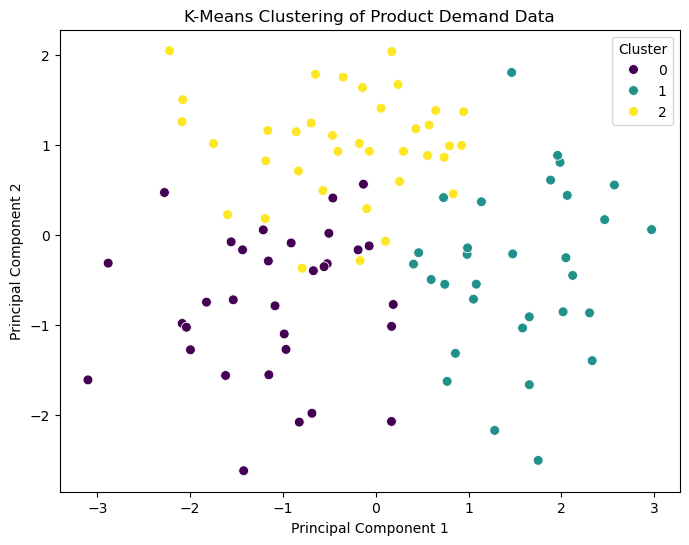

In [72]:
# Choose the optimal number of clusters
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
daily_data["Cluster"] = kmeans.fit_predict(dd_scaled)

# Visualizing cluster distribution using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(dd_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=daily_data["Cluster"], palette="viridis", s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Product Demand Data")
plt.legend(title="Cluster")
plt.show()

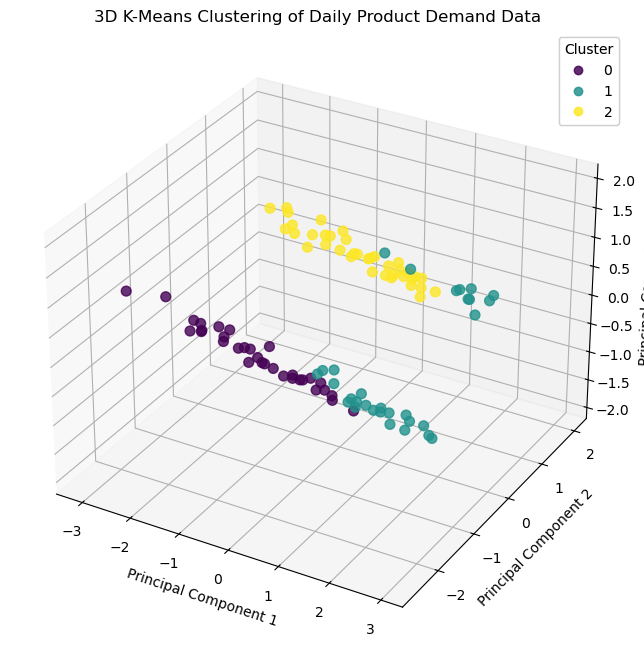

In [74]:
# Apply PCA with n_components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(dd_scaled)

# 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], 
                      c=daily_data["Cluster"], cmap="viridis", s=50, alpha=0.8)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D K-Means Clustering of Daily Product Demand Data")

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

In [76]:
# Choose the optimal number of clusters
optimal_k = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
daily_data["Cluster"] = kmeans.fit_predict(dd_scaled)

/var/folders/c4/lp7tf77d1j5_vh5zsl8h57_h0000gn/T/ipykernel_99098/3365825118.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data["Cluster"] = kmeans.fit_predict(dd_scaled)


/var/folders/c4/lp7tf77d1j5_vh5zsl8h57_h0000gn/T/ipykernel_99098/3133894727.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data["Cluster"] = daily_data["Cluster"].astype(str)


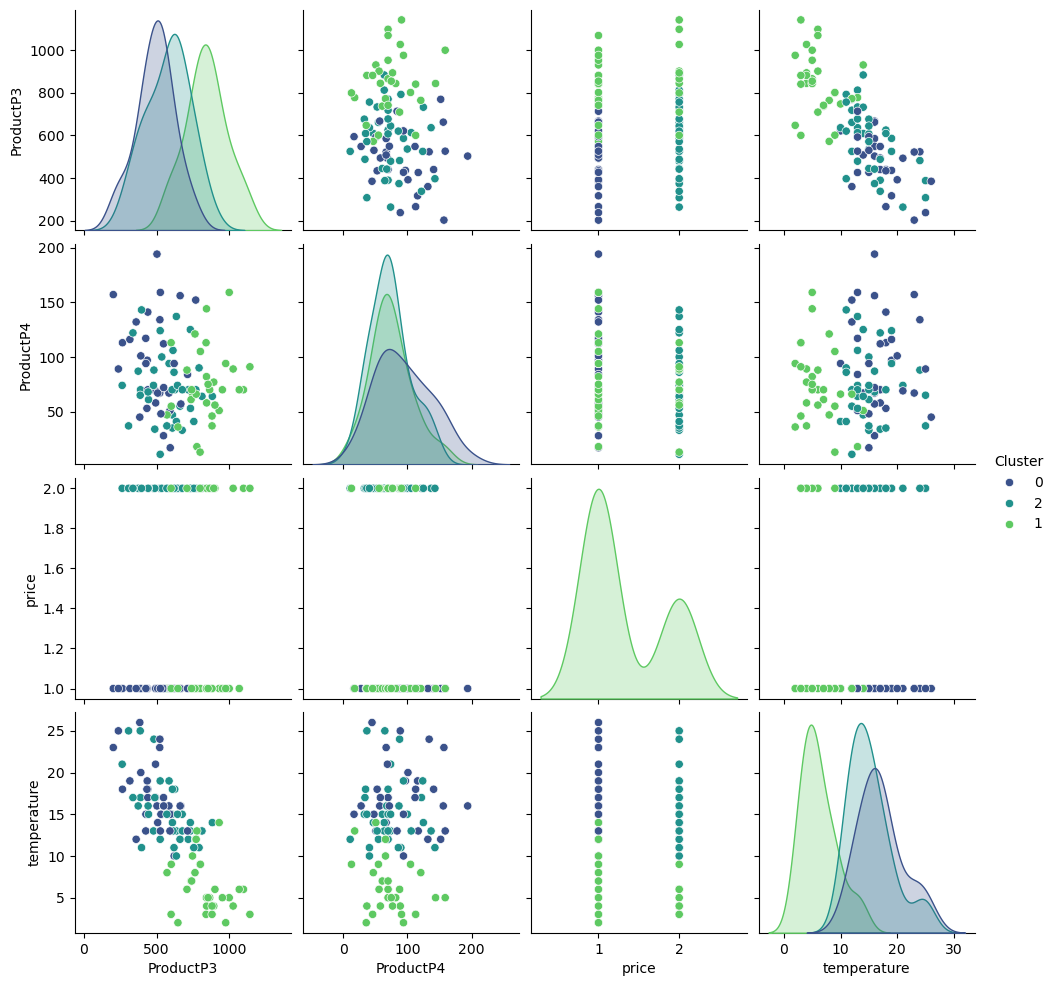

In [78]:
# Pair plot
daily_data["Cluster"] = daily_data["Cluster"].astype(str)
sns.pairplot(daily_data, hue="Cluster", palette="viridis", diag_kind="kde")